# Problem Statement -
Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

Data set - https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025$0

# 1. Data Reading

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
df = pd.read_csv("tesla_dataset.csv")

In [6]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [7]:
df.shape


(2640, 12)

In [8]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [10]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# 2. Data Cleaning and Preprocessing

### 2.1 Missing Value Analysis

In [11]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0




**Observation:**
No missing values were found in any of the 12 columns. Therefore, no imputation or missing-value treatment was required.

### 2.2 Duplicate Record Analysis

In [12]:
df.duplicated().sum()

np.int64(0)


**Observation:**
No duplicate records were found in the dataset. Therefore, no rows needed to be removed.

### 2.3 Outlier Analysis

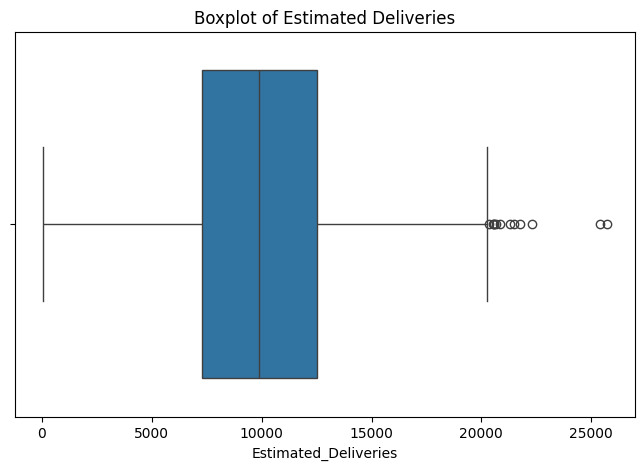

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Estimated_Deliveries'])
plt.title("Boxplot of Estimated Deliveries")
plt.show()

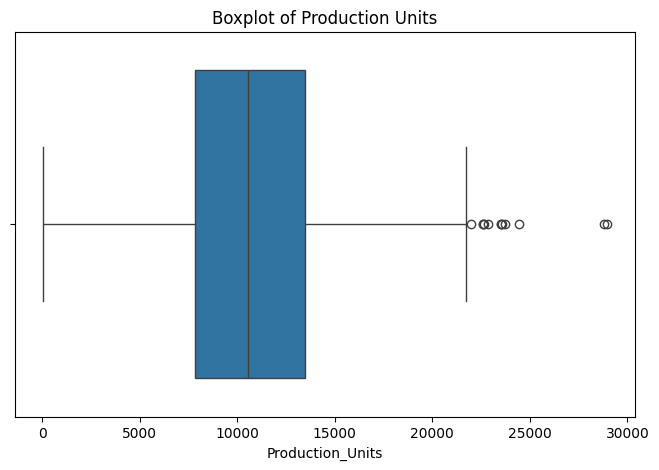

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Production_Units'])
plt.title("Boxplot of Production Units")
plt.show()

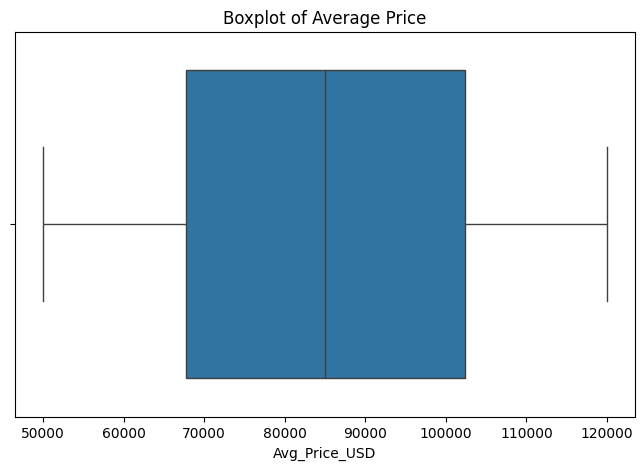

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Avg_Price_USD'])
plt.title("Boxplot of Average Price")
plt.show()

###  Outlier Analysis

Boxplots were used to identify potential outliers in key numerical variables such as Estimated Deliveries, Production Units, and Average Price.

**Observation:**

- A small number of high-value observations were detected in Estimated Deliveries and Production Units.
- These values are likely to represent genuine business variations rather than data-entry errors.
- No significant outliers were observed in Average Price.
- Therefore, no outlier removal was performed.

### 2.4 Consistency Check

In [16]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000




Descriptive statistics were examined using the `describe()` function to verify the validity and consistency of numerical features.

**Observation:**

- No negative or invalid values were detected.
- All numerical attributes fall within realistic business and operational ranges.
- The dataset appears to be clean and suitable for further analysis and modeling.

# 3. Exploratory Data Analysis (EDA)

## What is EDA?

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing data to understand its structure, identify patterns, detect anomalies, examine relationships between variables, and gain insights before building machine learning models.

The main objectives of EDA are:

- To understand the distribution of data.
- To identify trends and patterns.
- To detect missing values and outliers.
- To study relationships between features.
- To generate insights that can improve feature engineering and model performance.

In this project, EDA is performed on Tesla deliveries and production data to understand sales trends, production patterns, pricing behavior, and the relationships among different variables.

### 3.1 Distribution of Estimated Deliveries

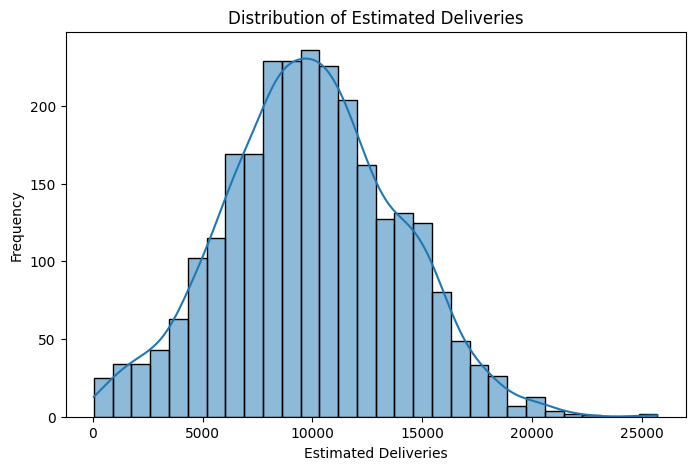

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

**Observation:**

The histogram illustrates the distribution of estimated deliveries across different observations. It helps identify the concentration of delivery values and any potential skewness in the data.

### 3.2 Distribution of Production Units

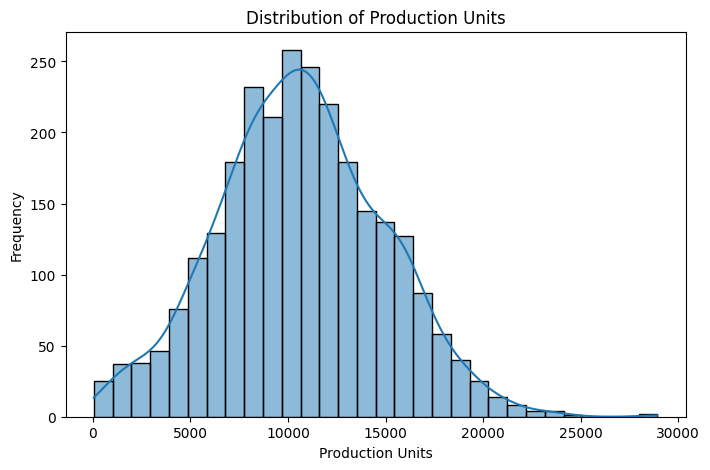

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Production_Units'],
    bins=30,
    kde=True
)

plt.title("Distribution of Production Units")
plt.xlabel("Production Units")
plt.ylabel("Frequency")

plt.show()

**Observation:**

This histogram shows the distribution of Tesla's production units. The visualization helps identify the most common production levels and highlights variations in manufacturing output.

### 3.3 Distribution of Average Price

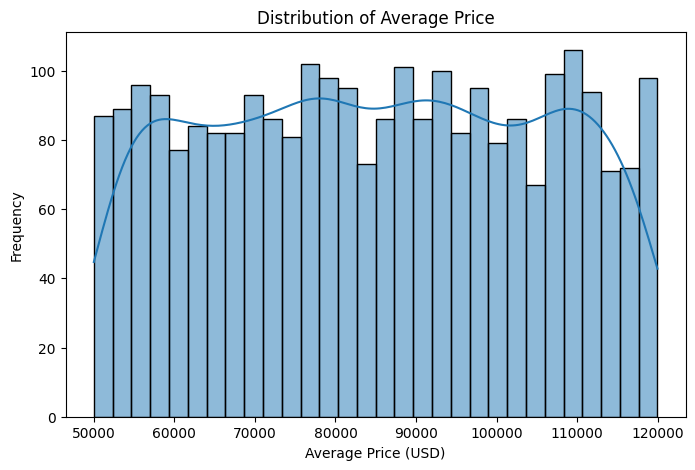

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Avg_Price_USD'],
    bins=30,
    kde=True
)

plt.title("Distribution of Average Price")
plt.xlabel("Average Price (USD)")
plt.ylabel("Frequency")

plt.show()

**Observation:**

The distribution illustrates the pricing pattern of Tesla vehicles. It helps understand the spread and concentration of vehicle prices across different models and regions.

### 3.4 Correlation Analysis

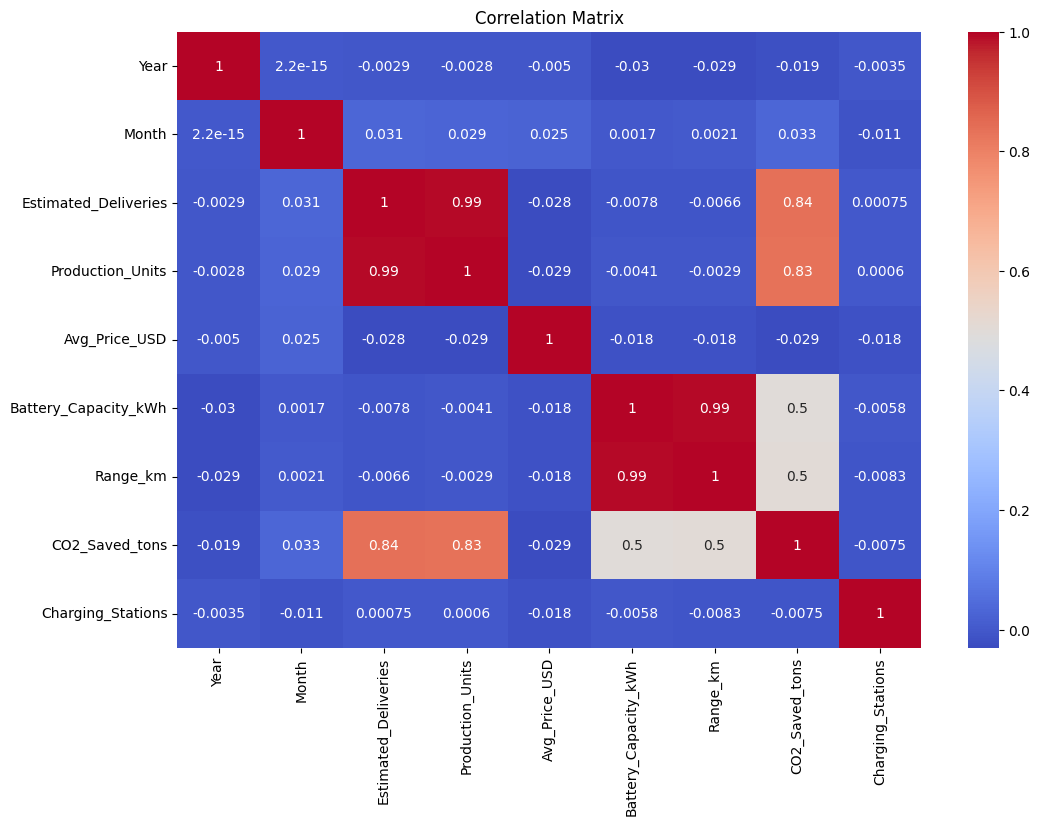

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

**Observation:**

- Estimated Deliveries and Production Units show a very strong positive correlation (0.99), indicating that higher production generally leads to higher deliveries.
- CO2 Saved has a strong positive correlation with both Estimated Deliveries (0.84) and Production Units (0.83), suggesting that increased vehicle deployment contributes significantly to carbon emission reduction.
- Battery Capacity and Range exhibit an extremely strong positive correlation (0.99), indicating that vehicles with larger battery capacities tend to offer greater driving range.
- Average Price shows very weak correlations with most variables, suggesting that pricing does not strongly influence the other numerical features in this dataset.
- Year, Month, and Charging Stations show minimal correlation with most variables.

### 3.5 Deliveries by Region

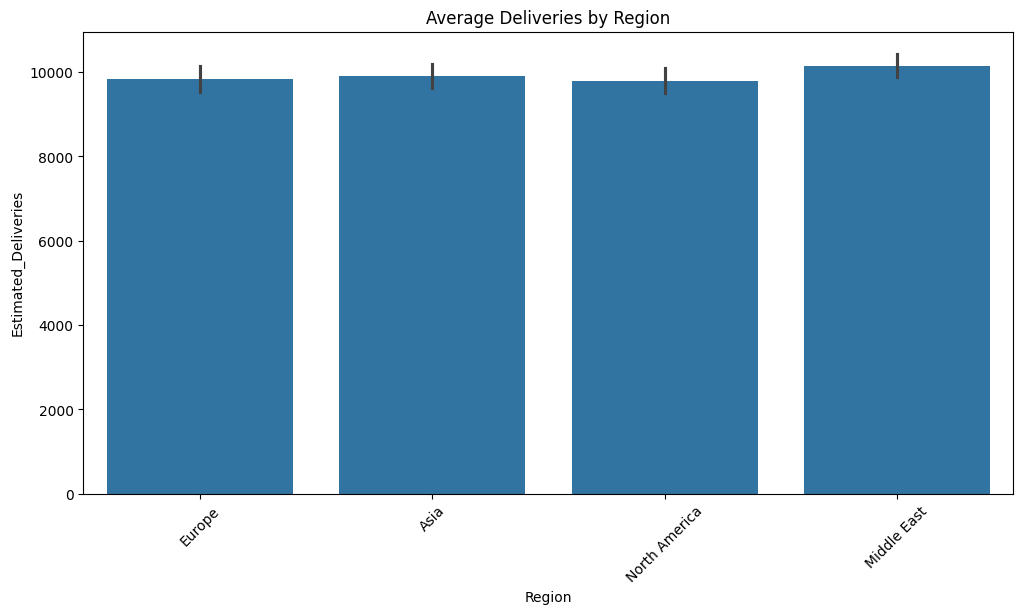

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Region',
    y='Estimated_Deliveries',
    estimator=np.mean
)

plt.title("Average Deliveries by Region")
plt.xticks(rotation=45)

plt.show()

### 3.6 Deliveries by Vehicle Model

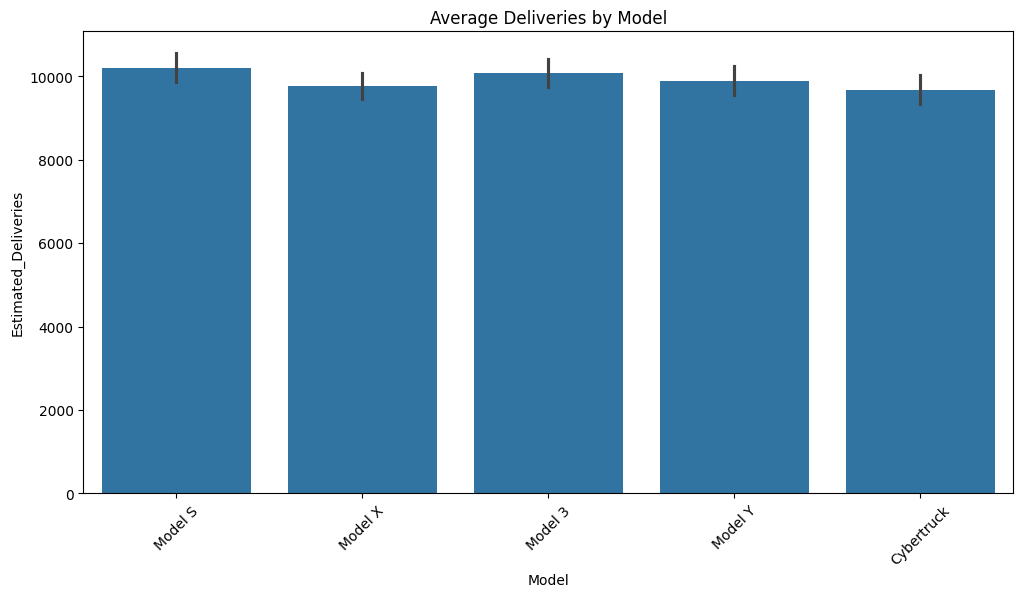

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries',
    estimator=np.mean
)

plt.title("Average Deliveries by Model")
plt.xticks(rotation=45)

plt.show()

### 3.7 Year-wise Delivery Trend

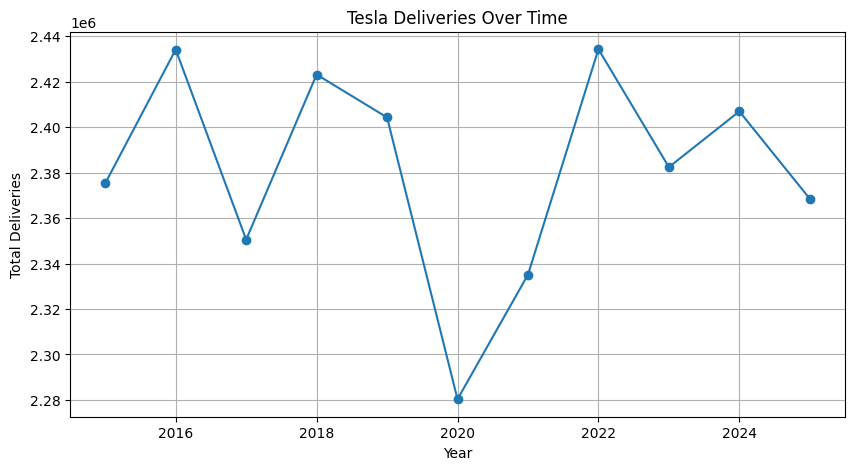

In [23]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_deliveries.index,
    yearly_deliveries.values,
    marker='o'
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")

plt.grid(True)

plt.show()

### 3.8 Production Trend Over Time

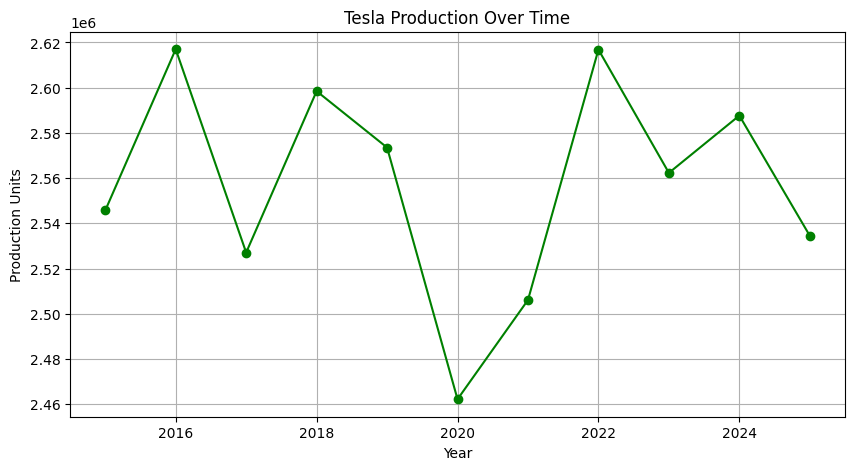

In [24]:
yearly_production = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_production.index,
    yearly_production.values,
    marker='o',
    color='green'
)

plt.title("Tesla Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production Units")

plt.grid(True)

plt.show()

**Observation:**

The production trend follows a pattern similar to deliveries, indicating a strong relationship between manufacturing output and customer deliveries.

### 3.9 Key Insights from EDA

### Key Findings

1. No missing values or duplicate records were found in the dataset.
2. Estimated Deliveries and Production Units exhibit a very strong positive correlation (0.99).
3. Battery Capacity and Vehicle Range are highly correlated (0.99).
4. CO2 Saved is strongly associated with both deliveries and production.
5. Regional and model-wise delivery differences are relatively small.
6. Deliveries and production show fluctuations across years with recovery after 2020.
7. Average Price demonstrates weak correlation with other numerical features.

# 4. Feature Engineering

## What is Feature Engineering?

Feature Engineering is the process of creating new variables from existing data that can help machine learning models better understand patterns and improve predictive performance.

In this project, additional features are created from existing Tesla sales and production data to enhance model learning and forecasting capability.

### 4.1 Creating Date Feature

In [25]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)

In [26]:
df[['Year','Month','Date']].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


**Observation:**

A new Date column was created by combining Year and Month, enabling time-series analysis and forecasting.

### 4.2 Creating Quarter Feature

In [27]:
df['Quarter'] = df['Date'].dt.quarter

df[['Date','Quarter']].head()

,Date,Quarter
0,2023-05-01,2
1,2015-02-01,1
2,2019-01-01,1
3,2021-02-01,1
4,2016-12-01,4


**Observation:**

Quarter information was extracted from the Date feature to capture seasonal business patterns.

### 4.3 Production Efficiency

In [28]:
df['Production_Efficiency'] = (
    df['Estimated_Deliveries']
    /
    df['Production_Units']
)

df[['Estimated_Deliveries',
    'Production_Units',
    'Production_Efficiency']].head()

,Estimated_Deliveries,Production_Units,Production_Efficiency
0,17646,17922,0.984600
1,3797,4164,0.911864
2,8411,9189,0.915334
3,6555,7311,0.896594
4,12374,13537,0.914087


**Observation:**

Production Efficiency measures how effectively produced vehicles are converted into delivered vehicles.

### 4.4 Price per Kilometer

In [29]:
df['Price_per_km'] = (
    df['Avg_Price_USD']
    /
    df['Range_km']
)

df[['Avg_Price_USD',
    'Range_km',
    'Price_per_km']].head()

,Avg_Price_USD,Range_km,Price_per_km
0,92874.27,704,131.923679
1,62205.65,438,142.022032
2,117887.32,480,245.598583
3,89294.91,712,125.414199
4,114846.78,661,173.747020


**Observation:**

Price per Kilometer represents the cost associated with each kilometer of driving range.

### 4.5 CO₂ Saved per Delivery

In [30]:
df['CO2_per_Delivery'] = (
    df['CO2_Saved_tons']
    /
    df['Estimated_Deliveries']
)

df[['CO2_Saved_tons',
    'Estimated_Deliveries',
    'CO2_per_Delivery']].head()

,CO2_Saved_tons,Estimated_Deliveries,CO2_per_Delivery
0,1863.42,17646,0.105600
1,249.46,3797,0.065699
2,605.59,8411,0.072000
3,700.07,6555,0.106799
4,1226.88,12374,0.099150


**Observation:**

This feature measures the average carbon emission reduction associated with each delivered vehicle.

In [31]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Production_Efficiency,Price_per_km,CO2_per_Delivery
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,0.984600,131.923679,0.105600
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,0.911864,142.022032,0.065699
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,0.915334,245.598583,0.072000
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,0.896594,125.414199,0.106799
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,0.914087,173.747020,0.099150


In [32]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Quarter',
       'Production_Efficiency', 'Price_per_km', 'CO2_per_Delivery'],
      dtype='object')

# 5. Regression Modeling

## What is Regression Modeling?

Regression Modeling is a supervised machine learning technique used to predict a continuous numerical value based on one or more input features.

The objective of regression is to learn the relationship between independent variables (features) and a dependent variable (target) so that future values can be estimated accurately.

In this project, regression models are developed to predict **Estimated Deliveries** using factors such as production units, vehicle specifications, pricing, charging infrastructure, and engineered features.

The performance of the regression models is evaluated using metrics such as:

- **MAE (Mean Absolute Error):** Measures the average prediction error.
- **RMSE (Root Mean Squared Error):** Measures the magnitude of prediction errors.
- **R² Score (Coefficient of Determination):** Indicates how well the model explains the variation in the target variable.

### 5.1 Encoding Categorical Features

Machine learning models require numerical inputs. Therefore, categorical variables were converted into numerical representations using Label Encoding.

In [33]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Production_Efficiency,Price_per_km,CO2_per_Delivery
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,2,0.984600,131.923679,0.105600
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,1,0.911864,142.022032,0.065699
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,1,0.915334,245.598583,0.072000
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,1,0.896594,125.414199,0.106799
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,4,0.914087,173.747020,0.099150


### 5.2 Defining Features and Target Variable

In [37]:
X = df.drop(
    [
        'Estimated_Deliveries',
        'Date',
        'Production_Efficiency',
        'CO2_per_Delivery'
    ],
    axis=1
)

y = df['Estimated_Deliveries']

print(X.shape)
print(y.shape)

(2640, 13)
(2640,)


### 5.3 Splitting the Dataset

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 13)
(528, 13)


### 5.4 Linear Regression Model

In [41]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2  :", r2_score(y_test, lr_pred))

MAE : 309.85349617841007
RMSE: 383.56285514410007
R2  : 0.9901303085969162


### 5.5 Random Forest Regression

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2  :", r2_score(y_test, rf_pred))

MAE : 324.8460606060606
RMSE: 410.891140731264
R2  : 0.9886738047718036


In [44]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

MAE : 324.8460606060606
RMSE: 410.891140731264
R2  : 0.9886738047718036


In [45]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [309.85, rf_mae],
    'RMSE': [383.56, rf_rmse],
    'R2 Score': [0.9901, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,309.850000,383.560000,0.990100
1,Random Forest,324.846061,410.891141,0.988674


### 5.6 Model Comparison

| Model | MAE | RMSE | R² Score |
|---------|---------|---------|---------|
| Linear Regression | 309.85 | 383.56 | 0.9901 |
| Random Forest | 324.84 | 410.89 | 0.9886 |

### Model Comparison Analysis

The performance of Linear Regression and Random Forest Regression models was compared using MAE, RMSE, and R² Score.

**Observation:**

- Linear Regression achieved the highest R² score (0.9901) and lower error values compared to Random Forest.
- Random Forest also demonstrated strong predictive capability with an R² score of 0.9887.
- The results indicate that the relationship between the selected features and Estimated Deliveries is largely linear.
- Based on the evaluation metrics, Linear Regression was selected as the best-performing regression model for this dataset.

# 6. Hyperparameter Tuning

## What is Hyperparameter Tuning?

Hyperparameter tuning is the process of finding the optimal set of model parameters that maximize predictive performance while minimizing prediction errors.

In [46]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best R2 Score:", grid.best_score_)

Best Parameters: {'max_depth': 15, 'n_estimators': 200}
Best R2 Score: 0.9885416618561074


### Hyperparameter Tuning Results

**Best Parameters Found:**

- max_depth = 15
- n_estimators = 200

**Best Cross-Validation R² Score:**

- R² = 0.9885

**Observation:**

GridSearchCV was used to identify the optimal hyperparameters for the Random Forest model. The best-performing configuration used 200 decision trees with a maximum depth of 15. The tuned model achieved a cross-validation R² score of 0.9885, indicating strong predictive performance.

# 7. Time Series Forecasting

## What is Time Series Forecasting?

Time Series Forecasting is a statistical and machine learning technique used to predict future values based on historical observations collected over time.

Unlike traditional regression models, time series forecasting considers the temporal order of data and identifies trends, seasonality, and patterns that evolve over time.

In this project, time series forecasting is used to analyze historical Tesla delivery data and estimate future delivery trends based on past performance.

### Objective

The objective of this section is to forecast future Tesla vehicle deliveries using historical monthly delivery data and identify potential future trends.

### 7.1 Preparing Time Series Data

In [47]:
ts = df.groupby('Date')['Estimated_Deliveries'].sum()

ts.head()

,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


### 7.2 Delivery Trend Over Time

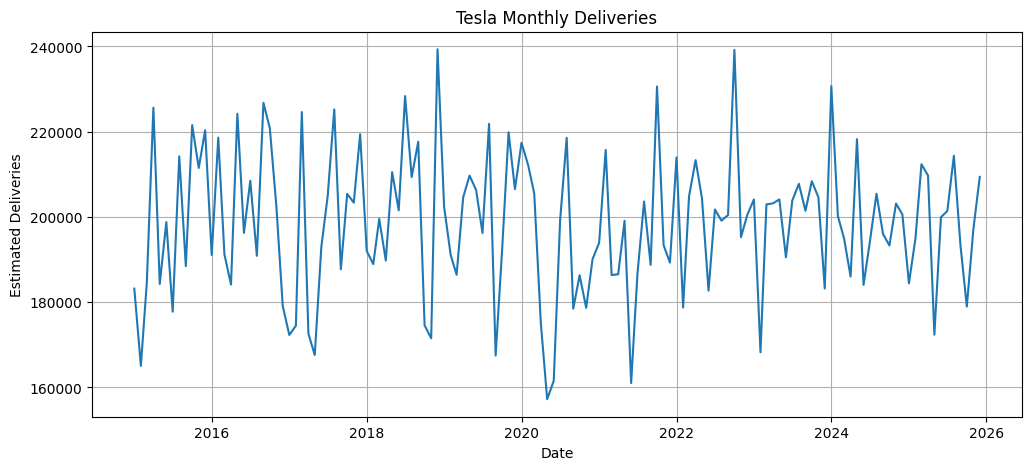

In [48]:
plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title("Tesla Monthly Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

### Observation

The monthly delivery trend exhibits fluctuations throughout the observation period, indicating varying demand and production levels over time. Despite short-term variations, the data maintains a consistent structure suitable for time series forecasting.

### 7.3 Forecasting Future Deliveries

In [49]:
!pip install prophet #  prophet an open-source machine learning library developed by Meta for time-series forecasting

In [50]:
forecast_df = ts.reset_index()

forecast_df.columns = ['ds', 'y'] # ds = date , y = target value

forecast_df.head()

,ds,y
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


In [51]:
# tarin forecastin model
from prophet import Prophet

model = Prophet()

model.fit(forecast_df)



INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [52]:
# forecast next 12 months
future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

forecast = model.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [53]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
132,2025-12-31,213529.706260,194855.610083,232814.457357
133,2026-01-31,185169.655353,166579.497694,203996.686404
134,2026-02-28,159843.866784,141647.033334,178333.191467
135,2026-03-31,226314.486069,207451.092181,244768.305696
136,2026-04-30,191242.025246,172681.227493,209585.656419
137,2026-05-31,210386.561699,191807.872480,229783.434744
138,2026-06-30,185025.726840,165297.364494,204335.017956
139,2026-07-31,214030.091480,195686.791988,233038.633564
140,2026-08-31,171945.664530,153668.897244,191936.536947
141,2026-09-30,207346.026096,188544.400449,226104.326148


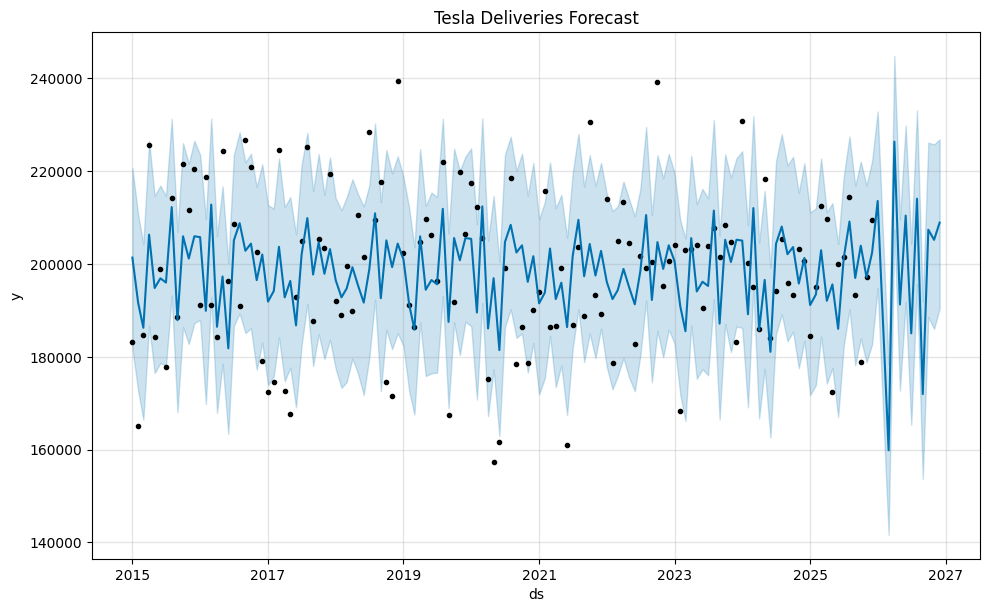

In [54]:
# plot
model.plot(forecast)
plt.title("Tesla Deliveries Forecast")
plt.show()

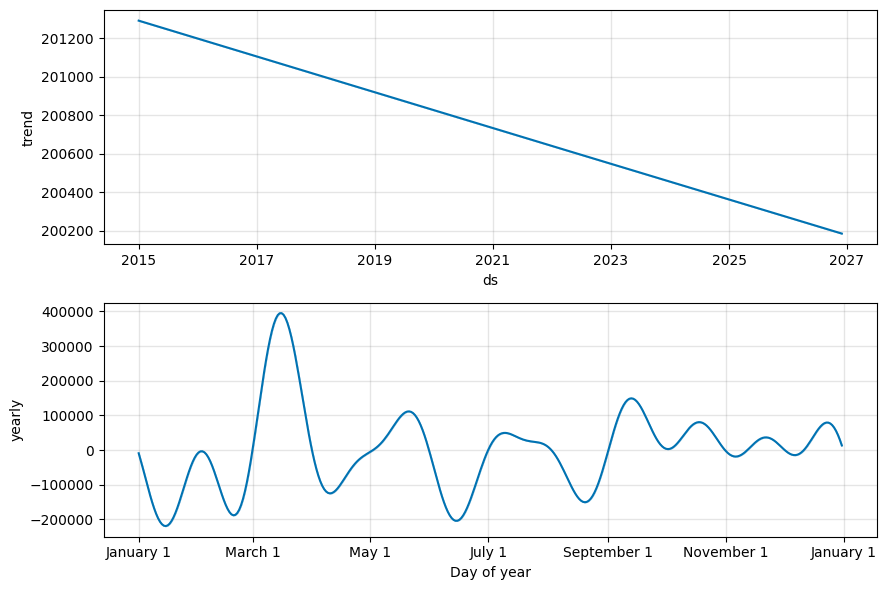

In [55]:
model.plot_components(forecast)
plt.show()

### 7.5 Forecast Interpretation

### Forecast Analysis

The Prophet model was trained using historical monthly Tesla delivery data and used to forecast future delivery volumes.

**Observations:**

- The forecast indicates relatively stable delivery volumes in the upcoming months.
- Historical delivery values fluctuate around the forecasted trend.
- The shaded region represents the uncertainty interval of the forecast.
- The model predicts that future deliveries are likely to remain within the historical range observed in the dataset.
- No strong long-term upward or downward trend is observed in the forecast period.

### Trend and Seasonality Analysis

The forecast components provide insights into the underlying patterns within the data.

**Observations:**

- The trend component shows a slight decline over the forecasting horizon.
- The yearly seasonality component indicates recurring fluctuations during specific periods of the year.
- Seasonal effects contribute to variations in delivery volumes across different months.
- Both trend and seasonal patterns are considered while generating future forecasts.

# 8. Conclusion

### Conclusion

This project successfully implemented an end-to-end machine learning pipeline on Tesla deliveries and production data.

### Work Performed

- Data loading and preprocessing
- Data cleaning and validation
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

### Key Findings

1. The dataset was clean and contained no missing values or duplicate records.
2. Estimated Deliveries and Production Units exhibited a very strong positive correlation.
3. Battery Capacity and Vehicle Range were highly correlated.
4. Linear Regression achieved the best performance with an R² score of approximately 0.9901.
5. Random Forest Regression also performed well with an R² score of approximately 0.9887.
6. Hyperparameter tuning identified the optimal Random Forest configuration as:
   - max_depth = 15
   - n_estimators = 200
7. Time series forecasting suggested relatively stable future delivery volumes with seasonal fluctuations.

### Final Outcome

The developed machine learning pipeline successfully analyzed historical Tesla delivery data, identified key business insights, built accurate predictive models, and generated future delivery forecasts. The project demonstrates the practical application of data preprocessing, machine learning, and forecasting techniques in a real-world business scenario.